In [2]:
import classical_2D as main
import quantum_2D as quant

import sys
sys.path.append("../funcs")

import geometry as geo
import kernals as ker
import metrics as met

import numpy as np
import matplotlib.pyplot as plt


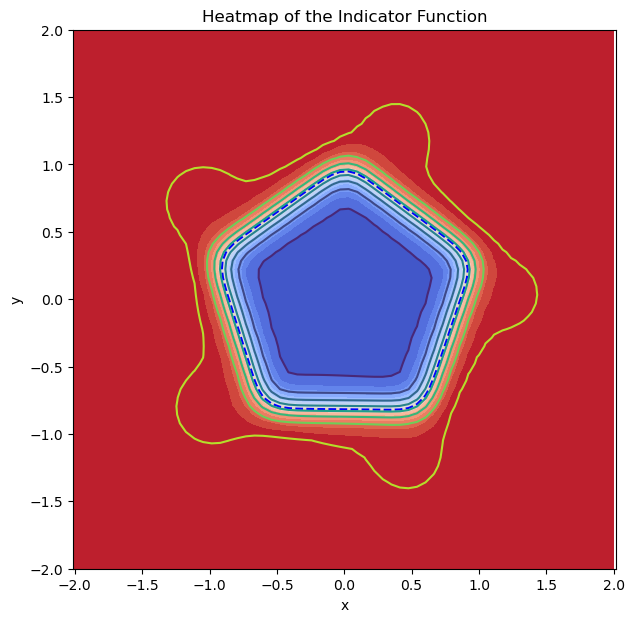

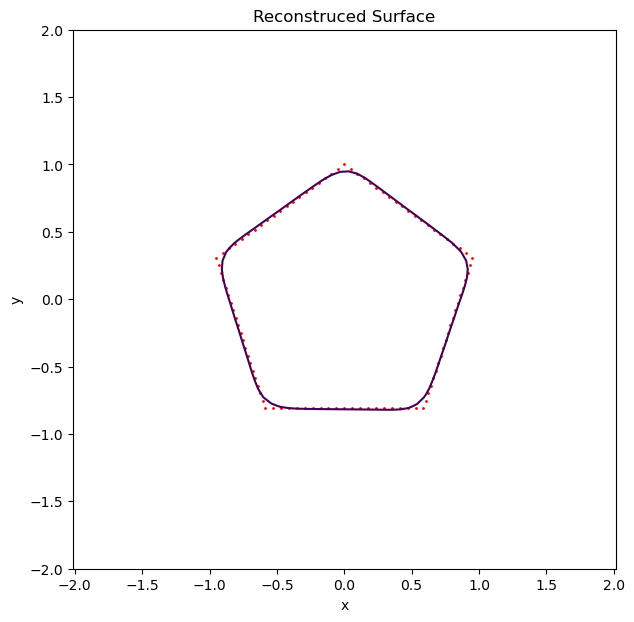

0.9763813710673401


In [3]:

size = 2

nx = 64
ny = 64

x = np.linspace(-size, size, nx)
y = np.linspace(-size, size, ny)

X, Y = np.meshgrid(x, y, indexing="ij")

scan_points, scan_normals = geo.generate_pentagon_points()

chi_grid, iso_value = main.surface_reconstruction(scan_points, scan_normals, size, nx, ny, ker.gaussian, sigma=0.1)


plt.figure(figsize=(7, 7))

plt.contour(
    X,
    Y,
    chi_grid,
    levels=[iso_value],
    colors="blue"
)

plt.contourf(X, Y, chi_grid, cmap="coolwarm", levels=20)
plt.contour(X, Y, chi_grid)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Heatmap of the Indicator Function")
plt.show()


fig, ax = plt.subplots(figsize=(7, 7))

contour = ax.contour(
    X,
    Y,
    chi_grid,
    levels=[iso_value]
)

ax.scatter(
    scan_points[:, 0],
    scan_points[:, 1],
    color="red",
    s=1,
    zorder=1
)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Reconstruced Surface")
plt.show()


iou = met.pentagon_vs_isosurface_iou(chi_grid, iso_value, x, y)
print(iou)


num =   8, Square IoU = 0.826879, Circle IoU = 0.968630, Pentagon IoU = 0.866940
num =  16, Square IoU = 0.935251, Circle IoU = 0.986148, Pentagon IoU = 0.937812
num =  32, Square IoU = 0.973180, Circle IoU = 0.993752, Pentagon IoU = 0.968283
num =  64, Square IoU = 0.981455, Circle IoU = 0.998711, Pentagon IoU = 0.976381


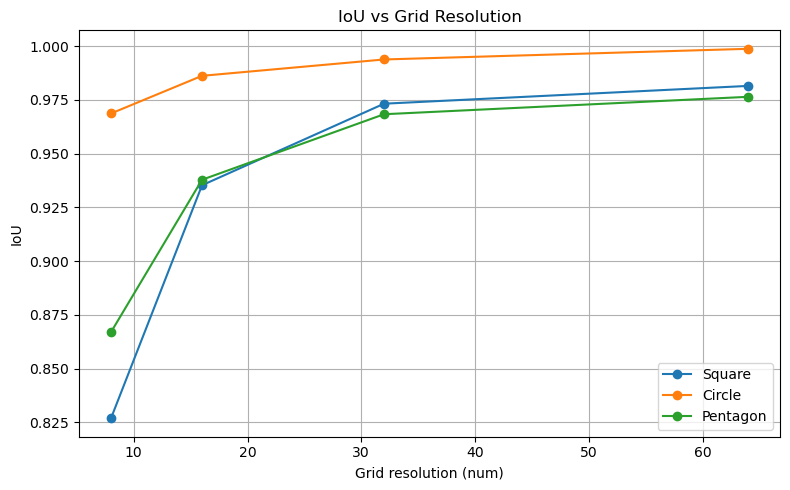

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

size = 2
num_values = [8, 16, 32, 64]

square_iou_values = []
circle_iou_values = []
pentagon_iou_values = []

for num in num_values:
    nx = num
    ny = num

    x = np.linspace(-size, size, nx)
    y = np.linspace(-size, size, ny)

    square_points, square_normals = geo.generate_square_points()
    chi_grid, iso_value = main.surface_reconstruction(square_points, square_normals, size, nx, ny, ker.gaussian, sigma=0.1)
    square_iou = met.square_vs_isosurface_iou(chi_grid, iso_value, x, y)
    square_iou_values.append(square_iou)


    circle_points, circle_normals = geo.generate_circle_points()
    chi_grid, iso_value = main.surface_reconstruction(circle_points, circle_normals, size, nx, ny, ker.gaussian, sigma=0.1)
    circle_iou = met.circle_vs_isosurface_iou(chi_grid, iso_value, x, y)
    circle_iou_values.append(circle_iou)
    
    pentagon_points, pentagon_normals = geo.generate_pentagon_points()
    chi_grid, iso_value = main.surface_reconstruction(pentagon_points, pentagon_normals, size, nx, ny, ker.gaussian, sigma=0.1)
    pentagon_iou = met.pentagon_vs_isosurface_iou(chi_grid, iso_value, x, y)
    pentagon_iou_values.append(pentagon_iou)

    print(
        f"num = {num:3d}, "
        f"Square IoU = {square_iou:.6f}, "
        f"Circle IoU = {circle_iou:.6f}, "
        f"Pentagon IoU = {pentagon_iou:.6f}"
    )



plt.figure(figsize=(8, 5))

plt.plot(
    num_values,
    square_iou_values,
    marker="o",
    label="Square"
)

plt.plot(
    num_values,
    circle_iou_values,
    marker="o",
    label="Circle"
)

plt.plot(
    num_values,
    pentagon_iou_values,
    marker="o",
    label="Pentagon"
)

plt.xlabel("Grid resolution (num)")
plt.ylabel("IoU")
plt.title("IoU vs Grid Resolution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()